In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix ,classification_report,precision_score, recall_score ,f1_score, roc_curve, roc_auc_score 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

In [2]:
df = pd.read_csv(r'D:\new project\BEC\BEC_Datasets1.csv')


In [3]:
df

,id,domain,email_id,outcome
0,1,examplecorp.com,ceo@examplecorp.com,safe
1,2,acmeinc.com,accounts@acmeinc.com,not safe
2,3,globalbizsolutions.net,finance@globalbizsolutions,safe
3,4,mycompanyllc.com,hr@mycompanyllc.com,not safe
4,5,techdynasty.org,admin@techdynasty.org,safe
...,...,...,...,...
595,596,healthblog.net,editor@healthblog.net,not safe
596,597,travelcompany.net,info@travelcompany.net,safe
597,598,petcareclinic.net,appointments@petcareclinic.net,not safe
598,599,marketingfirm.net,inquiries@marketingfirm.net,safe


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              600 non-null    int64 
 1   domain          600 non-null    object
 2   email_id        600 non-null    object
 3   outcome         600 non-null    object
 4   outcome_binary  600 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 23.6+ KB


In [10]:
df.describe()

,id,outcome_binary
count,600.000000,600.000000
mean,300.500000,0.506667
std,173.349358,0.500373
min,1.000000,0.000000
25%,150.750000,0.000000
50%,300.500000,1.000000
75%,450.250000,1.000000
max,600.000000,1.000000


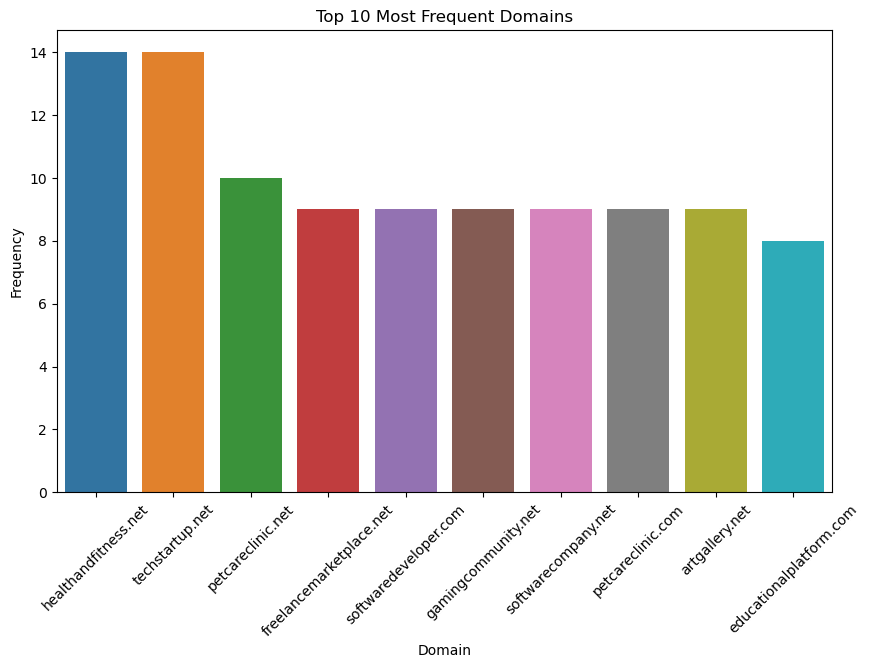

In [11]:
top_domains = df['domain'].value_counts().nlargest(10)  # Get top 10 most frequent domains
plt.figure(figsize=(10, 6))
sns.barplot(x=top_domains.index, y=top_domains.values)
plt.title('Top 10 Most Frequent Domains')
plt.xlabel('Domain')
plt.ylabel('Frequency')
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.show()

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


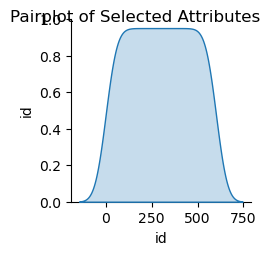

In [12]:
sns.pairplot(df[['id', 'email_id']], diag_kind='kde')  # Customize as per your attribute selection
plt.suptitle('Pairplot of Selected Attributes')
plt.show()

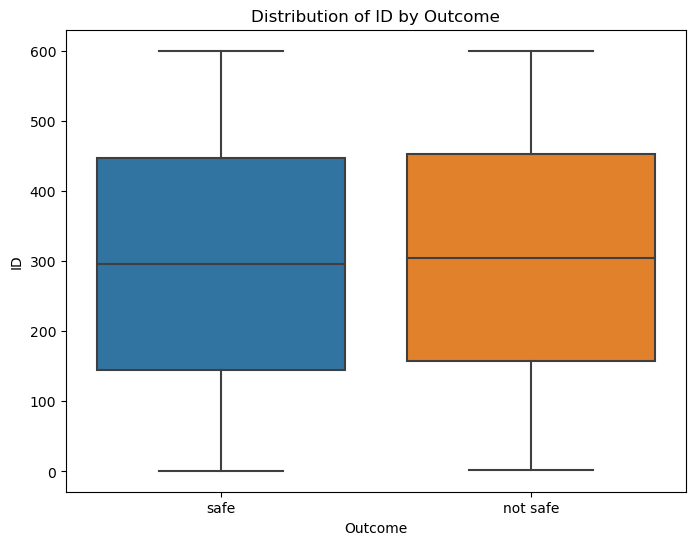

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='outcome', y='id', data=df)
plt.title('Distribution of ID by Outcome')
plt.xlabel('Outcome')
plt.ylabel('ID')
plt.show()

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Convert the 'outcome' column to a binary format
df['outcome_binary'] = df['outcome'].apply(lambda x: 1 if x == 'safe' else 0)

# Vectorize the email_id column using TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['email_id'])
y = df['outcome_binary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predict on the test set
y_pred = rf.predict(X_test)

# Generate a classification report
report = classification_report(y_test, y_pred)

print(report)


              precision    recall  f1-score   support

           0       0.89      0.86      0.87        84
           1       0.88      0.91      0.89        96

    accuracy                           0.88       180
   macro avg       0.88      0.88      0.88       180
weighted avg       0.88      0.88      0.88       180



In [6]:
import pickle

# Train the model on the full dataset
rf.fit(X, y)

# Save the trained model
model_path = 'random_forest_bec.pkl'
with open(model_path, 'wb') as model_file:
    pickle.dump(rf, model_file)

In [8]:
# Function to predict the outcome for a new email
def predict_outcome(email):
    email_vectorized = vectorizer.transform([email])
    prediction = rf.predict(email_vectorized)
    return "safe" if prediction[0] == 1 else "not safe"

# Example email for prediction
example_email = "chandan@mycompanyllc.com"
predicted_outcome = predict_outcome(example_email)

model_path, predicted_outcome


('random_forest_bec.pkl', 'safe')

In [14]:
import joblib

vectorizer_path = 'tfidf_vectorizer.pkl'
joblib.dump(vectorizer, vectorizer_path)


['tfidf_vectorizer.pkl']

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Assuming df is your DataFrame containing the columns 'email_id' and 'outcome'

# Convert the 'outcome' column to a binary format
df['outcome_binary'] = df['outcome'].apply(lambda x: 1 if x == 'safe' else 0)

# Vectorize the email_id column using TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['email_id'])
y = df['outcome_binary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the Decision Tree model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict on the test set
y_pred = dt.predict(X_test)

# Generate a classification report
report = classification_report(y_test, y_pred)

print(report)


              precision    recall  f1-score   support

           0       0.90      0.86      0.88        84
           1       0.88      0.92      0.90        96

    accuracy                           0.89       180
   macro avg       0.89      0.89      0.89       180
weighted avg       0.89      0.89      0.89       180



In [16]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Assuming df is your DataFrame containing the columns 'email_id' and 'outcome'

# Convert the 'outcome' column to a binary format
df['outcome_binary'] = df['outcome'].apply(lambda x: 1 if x == 'safe' else 0)

# Vectorize the email_id column using TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['email_id'])
y = df['outcome_binary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the Naive Bayes model
nb = MultinomialNB()
nb.fit(X_train, y_train)

# Predict on the test set
y_pred = nb.predict(X_test)

# Generate a classification report
report = classification_report(y_test, y_pred)

print(report)


              precision    recall  f1-score   support

           0       0.88      0.89      0.89        84
           1       0.91      0.90      0.90        96

    accuracy                           0.89       180
   macro avg       0.89      0.89      0.89       180
weighted avg       0.89      0.89      0.89       180



In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Assuming df is your DataFrame containing the columns 'email_id' and 'outcome'

# Convert the 'outcome' column to a binary format
df['outcome_binary'] = df['outcome'].apply(lambda x: 1 if x == 'safe' else 0)

# Vectorize the email_id column using TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['email_id'])
y = df['outcome_binary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the Logistic Regression model
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

# Predict on the test set
y_pred = lr.predict(X_test)

# Generate a classification report
report = classification_report(y_test, y_pred)

print(report)


              precision    recall  f1-score   support

           0       0.90      0.88      0.89        84
           1       0.90      0.92      0.91        96

    accuracy                           0.90       180
   macro avg       0.90      0.90      0.90       180
weighted avg       0.90      0.90      0.90       180



In [18]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Assuming df is your DataFrame containing the columns 'email_id' and 'outcome'

# Convert the 'outcome' column to a binary format
df['outcome_binary'] = df['outcome'].apply(lambda x: 1 if x == 'safe' else 0)

# Vectorize the email_id column using TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['email_id'])
y = df['outcome_binary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the SVM model
svm = SVC(random_state=42)
svm.fit(X_train, y_train)

# Predict on the test set
y_pred = svm.predict(X_test)

# Generate a classification report
report = classification_report(y_test, y_pred)

print(report)


              precision    recall  f1-score   support

           0       0.91      0.85      0.88        84
           1       0.87      0.93      0.90        96

    accuracy                           0.89       180
   macro avg       0.89      0.89      0.89       180
weighted avg       0.89      0.89      0.89       180



In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Assuming df is your DataFrame containing the columns 'email_id' and 'outcome'

# Convert the 'outcome' column to a binary format
df['outcome_binary'] = df['outcome'].apply(lambda x: 1 if x == 'safe' else 0)

# Vectorize the email_id column using TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['email_id'])
y = df['outcome_binary']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Generate a classification report
report = classification_report(y_test, y_pred)

print(report)


              precision    recall  f1-score   support

           0       0.91      0.85      0.88        84
           1       0.87      0.93      0.90        96

    accuracy                           0.89       180
   macro avg       0.89      0.89      0.89       180
weighted avg       0.89      0.89      0.89       180

